In [3]:
import pandas as pd
import numpy as np
import nltk
import string
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vasu5\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [7]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [8]:
df["text"] = df["Ticket Type"] + " " + df["Ticket Description"]

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,text
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,Technical issue I'm having an issue with the {...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,Technical issue I'm having an issue with the {...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Technical issue I'm facing a problem with my {...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Billing inquiry I'm having an issue with the {...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Billing inquiry I'm having an issue with the {...


In [9]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

In [10]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_text"])

In [11]:
y = df["Ticket Type"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = MultinomialNB()

model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [14]:
y_pred = model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8807556080283353
                      precision    recall  f1-score   support

     Billing inquiry       0.84      0.84      0.84       357
Cancellation request       0.93      0.93      0.93       327
     Product inquiry       0.78      0.72      0.75       316
      Refund request       0.90      0.95      0.92       345
     Technical issue       0.94      0.95      0.95       349

            accuracy                           0.88      1694
           macro avg       0.88      0.88      0.88      1694
        weighted avg       0.88      0.88      0.88      1694



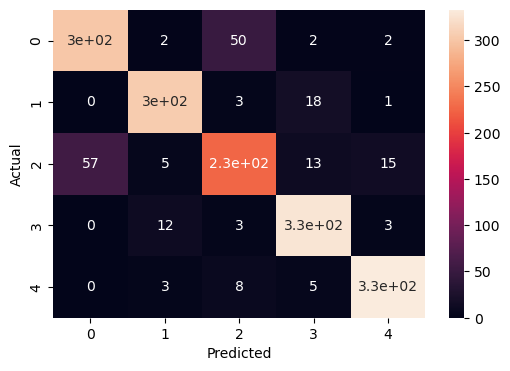

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
ticket = ["My payment was charged twice and I need a refund"]

ticket_vector = vectorizer.transform(ticket)

prediction = model.predict(ticket_vector)

print("Predicted Ticket Category:", prediction[0])

Predicted Ticket Category: Refund request


In [18]:
y_priority = df["Ticket Priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

priority_model = MultinomialNB()

priority_model.fit(X_train, y_train)

priority_pred = priority_model.predict(X_test)

print("Priority Accuracy:", accuracy_score(y_test, priority_pred))

Priority Accuracy: 0.2526564344746163


In [19]:
import pickle

pickle.dump(model, open("ticket_category_model.pkl","wb"))

pickle.dump(priority_model, open("ticket_priority_model.pkl","wb"))

pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

In [22]:
import pandas as pd
import nltk
import string
import pickle

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

nltk.download("stopwords")

# Load dataset
df = pd.read_csv("customer_support_tickets.csv")

# Use ONLY ticket description
df["text"] = df["Ticket Description"]

# Clean text
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

# Vectorization
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_text"])

y = df["Ticket Type"]

# Train model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB()

model.fit(X_train, y_train)

# Save model again
pickle.dump(model, open("ticket_model.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vasu5\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
